Today's topics:
* `bool` — a third basic type, and how comparisons produce it
* `df[mask]` — boolean indexing, a third selection style alongside `.loc`/`.iloc`
* combining conditions with `&`, `|`, `~`
* missing data: `isna`, `notna`, `dropna`

> HW4: multi-condition masks and NaN handling on a real dataset

# A third basic type: `bool`

In [1]:
type(True)

bool

`bool` is secretly `int` — `True` acts like `1`, `False` like `0`:

In [2]:
print(True == 1)
print(False == 0)
print(True + True)

True
True
2


*How do you get a `bool` in the first place?* Comparisons:

In [3]:
x = 7
print(x > 5)
print(x == 7)
print(x != 7)

True
True
False


`==`, `!=`, `<`, `<=`, `>`, `>=`

`=` assigns. `==` asks a question. Don't confuse them:

In [4]:
x = 7        # assigns 7 to x
print(x)

7


In [5]:
print(x == 7)  # asks: is x equal to 7? Answer: True

True


Same elementwise pattern as `+`, `-`, `*` on an array/Series — just with `>`.

# Comparing a whole column at once

Elements dataset from Lecture 8 — 52 elements, real `NaN` gaps.

## Dataset: Elemental Properties

This dataset contains physical and electronic properties of chemical elements,
including atomic mass, ionization energies, vacancy formation energies,
bulk static energies, and crystal structures.

Note that some entries contain `NaN` (Not a Number) values where data was
unavailable. We'll need to handle these when performing calculations.

In [6]:
import os
import pandas as pd

_file = 'elements.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e
data

,Symbol,Bulk Static Energy (eV),Reference Energy (eV),Clean Cohesive,Cohesive Energy (eV),Cohesive Energy Per Atom (eV),Atomic Number,Mendeleev Number,Atomic Mass,STP Phase,Natural Crystal Structure,Vacancy Formation Energy (eV),"Vacancy Migration Energy, non-disp (eV)","Vacancy Migration Energy, disp (eV)",Experimental Hvac,Experimental Hmig,Activation Energy (eV),NEBimageVolume,Ionization Energies (eV)
0,Ac,-442.228190,-0.25,1.0,415.09,3.843385,89,48,227.0000,solid,fcc,1.259565,0.460300,0.454340,NaN,NaN,1.719865,4900.00,5.170000
1,Ag,-305.971040,-0.35,1.0,268.38,2.485000,47,71,107.8600,solid,fcc,0.683455,0.695180,0.695030,1.12,0.60,1.378635,1930.00,7.576230
2,Al,-403.993240,-0.23,1.0,379.35,3.512481,13,80,26.9815,solid,fcc,0.607072,0.581350,0.581650,0.68,0.68,1.188422,1779.29,5.985768
3,Ar,-7.404033,-0.05,1.0,1.71,0.015855,18,3,39.9480,gas,fcc,0.049976,0.020634,NaN,NaN,NaN,0.070610,4859.00,15.759610
4,Au,-353.846200,-0.28,1.0,323.28,2.993363,79,70,196.9700,solid,fcc,0.400096,0.548710,0.547920,0.89,0.84,0.948806,1951.89,9.225530
5,Ba,NaN,NaN,0.0,0.00,0.000000,56,14,137.3200,solid,bcc,1.085024,0.000000,NaN,NaN,NaN,1.085024,0.00,5.211664
6,Be,-395.309910,-0.01,1.0,394.12,3.649236,4,77,9.0120,solid,hcp,-0.062697,0.750210,0.750340,NaN,NaN,0.687513,851.00,9.322700
7,Ca,-216.424440,-0.13,1.0,202.14,1.871703,20,16,40.0780,solid,fcc,1.133600,0.470580,NaN,NaN,NaN,1.604180,4554.00,6.113160
8,Cd,NaN,NaN,0.0,0.00,0.000000,48,75,112.4110,solid,hcp,0.302081,0.000000,NaN,0.45,NaN,0.302081,0.00,8.993820
9,Ce,-640.664090,-1.27,1.0,503.70,4.663924,58,32,140.1160,solid,fcc,1.298365,0.544760,NaN,NaN,NaN,1.843125,2818.00,5.538700


*What does comparing a whole column give back?*

In [7]:
data['Vacancy Formation Energy (eV)'] > 1.0

0      True
1     False
2     False
3     False
4     False
5      True
6     False
7      True
8     False
9      True
10     True
11     True
12     True
13     True
14     True
15    False
16    False
17    False
18     True
19     True
20    False
21     True
22    False
23    False
24     True
25    False
26    False
27     True
28    False
29    False
30     True
31     True
32    False
33     True
34    False
35    False
36     True
37     True
38     True
39     True
40    False
41     True
42     True
43     True
44     True
45     True
46    False
47    False
48     True
49    False
50     True
51     True
Name: Vacancy Formation Energy (eV), dtype: bool

52 `True`/`False` values, one per row — a **mask**.

In [8]:
mask = data['Vacancy Formation Energy (eV)'] > 1.0
mask

0      True
1     False
2     False
3     False
4     False
5      True
6     False
7      True
8     False
9      True
10     True
11     True
12     True
13     True
14     True
15    False
16    False
17    False
18     True
19     True
20    False
21     True
22    False
23    False
24     True
25    False
26    False
27     True
28    False
29    False
30     True
31     True
32    False
33     True
34    False
35    False
36     True
37     True
38     True
39     True
40    False
41     True
42     True
43     True
44     True
45     True
46    False
47    False
48     True
49    False
50     True
51     True
Name: Vacancy Formation Energy (eV), dtype: bool

`bool` is secretly `int` → `.sum()` counts, `.mean()` gives a proportion:

In [9]:
mask.sum()

np.int64(29)

In [10]:
mask.mean()

np.float64(0.5576923076923077)

### [Check your understanding]

* Before running: guess `mask.sum()` out of 52 elements
* Run the cell above again and check

# Using the mask to filter rows

Hand the mask back to `data` as an index:

In [11]:
high_vacancy = data[data['Vacancy Formation Energy (eV)'] > 1.0]
high_vacancy[['Symbol', 'Vacancy Formation Energy (eV)']]

,Symbol,Vacancy Formation Energy (eV)
0,Ac,1.259565
5,Ba,1.085024
7,Ca,1.133600
9,Ce,1.298365
10,Co,1.841825
11,Cu,1.066309
12,Dy,1.716888
13,Er,1.023558
14,Fe,2.319890
18,Hf,2.088726


## Seeing the mask

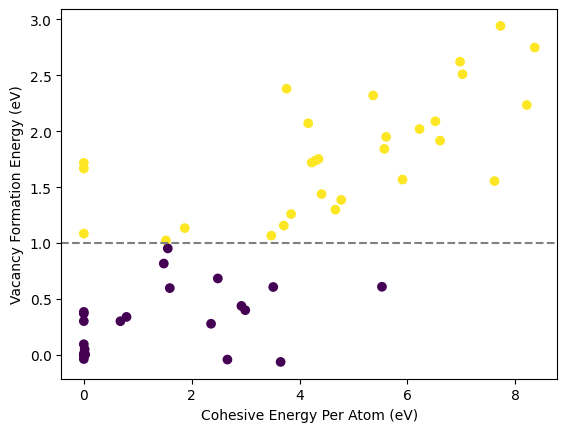

In [12]:
import matplotlib.pyplot as plt

plt.scatter(data['Cohesive Energy Per Atom (eV)'], data['Vacancy Formation Energy (eV)'], c=mask)
plt.axhline(1.0, color='gray', linestyle='--')
plt.xlabel('Cohesive Energy Per Atom (eV)')
plt.ylabel('Vacancy Formation Energy (eV)')
plt.show()

A third indexing style:

| Syntax | Selects rows by... |
|---|---|
| `data.loc[label]` | row label |
| `data.iloc[position]` | row position |
| `data[mask]` | boolean Series — keep `True` rows |

Mask written inline, no intermediate variable — completely normal:

In [13]:
data[data['Natural Crystal Structure'] == 'bcc']

,Symbol,Bulk Static Energy (eV),Reference Energy (eV),Clean Cohesive,Cohesive Energy (eV),Cohesive Energy Per Atom (eV),Atomic Number,Mendeleev Number,Atomic Mass,STP Phase,Natural Crystal Structure,Vacancy Formation Energy (eV),"Vacancy Migration Energy, non-disp (eV)","Vacancy Migration Energy, disp (eV)",Experimental Hvac,Experimental Hmig,Activation Energy (eV),NEBimageVolume,Ionization Energies (eV)
5,Ba,NaN,NaN,0.0,0.00,0.000000,56,14,137.3200,solid,bcc,1.085024,0.00000,NaN,NaN,NaN,1.085024,0.00,5.211664
14,Fe,-880.18703,-2.79,1.0,579.36,5.364450,26,61,55.8450,solid,bcc,2.319890,1.38239,1.38238,1.4,1.26,3.702280,1104.00,7.902400
22,K,-118.35842,-0.30,1.0,85.48,0.791497,19,10,39.0983,solid,bcc,0.339779,0.15595,NaN,NaN,NaN,0.495729,7948.39,4.340663
25,Li,-205.67889,-0.31,1.0,172.19,1.594369,3,12,6.9410,solid,bcc,0.597416,0.13281,0.13043,NaN,NaN,0.730226,2184.00,5.391719
35,Rb,-103.90293,-0.28,1.0,73.28,0.678507,37,9,85.4700,solid,bcc,0.301446,0.13863,NaN,NaN,NaN,0.440076,9807.00,4.177128
41,Ta,-1254.06200,-3.40,1.0,887.14,8.214243,73,52,180.9480,solid,bcc,2.234215,-0.35380,NaN,NaN,NaN,1.880415,2012.00,7.549570
47,V,NaN,NaN,NaN,0.00,0.000000,23,54,50.9415,solid,bcc,-0.037017,0.00000,NaN,NaN,NaN,-0.037017,0.00,6.746190
48,W,NaN,NaN,NaN,0.00,0.000000,74,55,183.8400,solid,bcc,1.665803,0.00000,NaN,NaN,NaN,1.665803,0.00,7.864030


Same brackets, three jobs: `data['col']` selects a column, `data['col'] == 'bcc'` builds a condition, `data[condition]` selects rows.

> **Read more:** [PDSH — Comparisons, Masks, and Boolean Logic](https://jakevdp.github.io/PythonDataScienceHandbook/02.06-boolean-arrays-and-masks.html)

### [Check your understanding]

* Predict, no code: what does `data[data['Atomic Number'] < 10]` give you? How many rows?

# Combining conditions: `&`, `|`, `~`

*Which elements have high vacancy formation energy **and** a known experimental value?*

Tempting first move — Python's `and`:

In [14]:
cond1 = data['Vacancy Formation Energy (eV)'] > 1.0
cond2 = data['Experimental Hvac'].notna()

try:
    data[cond1 and cond2]
except ValueError as e:
    print('ValueError:', e)

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().


`and`/`or` expect one `True`/`False`, not 52. Use `&`, `|`, `~` — elementwise, like `+` and `>`. Parenthesize each condition:

In [15]:
data[cond1 & cond2]

,Symbol,Bulk Static Energy (eV),Reference Energy (eV),Clean Cohesive,Cohesive Energy (eV),Cohesive Energy Per Atom (eV),Atomic Number,Mendeleev Number,Atomic Mass,STP Phase,Natural Crystal Structure,Vacancy Formation Energy (eV),"Vacancy Migration Energy, non-disp (eV)","Vacancy Migration Energy, disp (eV)",Experimental Hvac,Experimental Hmig,Activation Energy (eV),NEBimageVolume,Ionization Energies (eV)
10,Co,-746.51927,-1.34,1.0,601.82,5.572443,27,64,58.9332,solid,hcp,1.841825,1.44915,1.44897,1.71,0.98,3.290975,1111.92,7.88101
11,Cu,-402.33138,-0.25,1.0,375.52,3.477061,29,72,63.5460,solid,fcc,1.066309,0.71719,0.71700,1.29,0.78,1.783499,1292.22,7.72638
14,Fe,-880.18703,-2.79,1.0,579.36,5.364450,26,61,55.8450,solid,bcc,2.319890,1.38239,1.38238,1.40,1.26,3.702280,1104.00,7.90240
30,Ni,-596.08800,-0.75,1.0,515.46,4.772756,28,67,58.6934,solid,fcc,1.385617,0.94543,0.94461,1.40,1.32,2.331047,1171.41,7.63980
33,Pd,-559.84839,-1.48,1.0,400.45,3.707836,46,69,106.4200,solid,fcc,1.156599,0.94965,0.94877,1.85,0.91,2.106249,1659.64,8.33690


Usually written inline — the exact shape HW4 expects:

In [16]:
data[(data['Vacancy Formation Energy (eV)'] > 1.0) & (data['Experimental Hvac'].notna())]

,Symbol,Bulk Static Energy (eV),Reference Energy (eV),Clean Cohesive,Cohesive Energy (eV),Cohesive Energy Per Atom (eV),Atomic Number,Mendeleev Number,Atomic Mass,STP Phase,Natural Crystal Structure,Vacancy Formation Energy (eV),"Vacancy Migration Energy, non-disp (eV)","Vacancy Migration Energy, disp (eV)",Experimental Hvac,Experimental Hmig,Activation Energy (eV),NEBimageVolume,Ionization Energies (eV)
10,Co,-746.51927,-1.34,1.0,601.82,5.572443,27,64,58.9332,solid,hcp,1.841825,1.44915,1.44897,1.71,0.98,3.290975,1111.92,7.88101
11,Cu,-402.33138,-0.25,1.0,375.52,3.477061,29,72,63.5460,solid,fcc,1.066309,0.71719,0.71700,1.29,0.78,1.783499,1292.22,7.72638
14,Fe,-880.18703,-2.79,1.0,579.36,5.364450,26,61,55.8450,solid,bcc,2.319890,1.38239,1.38238,1.40,1.26,3.702280,1104.00,7.90240
30,Ni,-596.08800,-0.75,1.0,515.46,4.772756,28,67,58.6934,solid,fcc,1.385617,0.94543,0.94461,1.40,1.32,2.331047,1171.41,7.63980
33,Pd,-559.84839,-1.48,1.0,400.45,3.707836,46,69,106.4200,solid,fcc,1.156599,0.94965,0.94877,1.85,0.91,2.106249,1659.64,8.33690


`|` — "either/or":

In [17]:
data[(data['Natural Crystal Structure'] == 'bcc') | (data['Natural Crystal Structure'] == 'fcc')]

,Symbol,Bulk Static Energy (eV),Reference Energy (eV),Clean Cohesive,Cohesive Energy (eV),Cohesive Energy Per Atom (eV),Atomic Number,Mendeleev Number,Atomic Mass,STP Phase,Natural Crystal Structure,Vacancy Formation Energy (eV),"Vacancy Migration Energy, non-disp (eV)","Vacancy Migration Energy, disp (eV)",Experimental Hvac,Experimental Hmig,Activation Energy (eV),NEBimageVolume,Ionization Energies (eV)
0,Ac,-442.228190,-0.25,1.0,415.09,3.843385,89,48,227.0000,solid,fcc,1.259565,0.460300,0.454340,NaN,NaN,1.719865,4900.00,5.170000
1,Ag,-305.971040,-0.35,1.0,268.38,2.485000,47,71,107.8600,solid,fcc,0.683455,0.695180,0.695030,1.12,0.60,1.378635,1930.00,7.576230
2,Al,-403.993240,-0.23,1.0,379.35,3.512481,13,80,26.9815,solid,fcc,0.607072,0.581350,0.581650,0.68,0.68,1.188422,1779.29,5.985768
3,Ar,-7.404033,-0.05,1.0,1.71,0.015855,18,3,39.9480,gas,fcc,0.049976,0.020634,NaN,NaN,NaN,0.070610,4859.00,15.759610
4,Au,-353.846200,-0.28,1.0,323.28,2.993363,79,70,196.9700,solid,fcc,0.400096,0.548710,0.547920,0.89,0.84,0.948806,1951.89,9.225530
5,Ba,NaN,NaN,0.0,0.00,0.000000,56,14,137.3200,solid,bcc,1.085024,0.000000,NaN,NaN,NaN,1.085024,0.00,5.211664
7,Ca,-216.424440,-0.13,1.0,202.14,1.871703,20,16,40.0780,solid,fcc,1.133600,0.470580,NaN,NaN,NaN,1.604180,4554.00,6.113160
9,Ce,-640.664090,-1.27,1.0,503.70,4.663924,58,32,140.1160,solid,fcc,1.298365,0.544760,NaN,NaN,NaN,1.843125,2818.00,5.538700
11,Cu,-402.331380,-0.25,1.0,375.52,3.477061,29,72,63.5460,solid,fcc,1.066309,0.717190,0.717000,1.29,0.78,1.783499,1292.22,7.726380
14,Fe,-880.187030,-2.79,1.0,579.36,5.364450,26,61,55.8450,solid,bcc,2.319890,1.382390,1.382380,1.40,1.26,3.702280,1104.00,7.902400


`.isin([...])` — shorter spelling for repeated `|`-of-`==`:

In [18]:
data[data['Natural Crystal Structure'].isin(['bcc', 'fcc'])]

,Symbol,Bulk Static Energy (eV),Reference Energy (eV),Clean Cohesive,Cohesive Energy (eV),Cohesive Energy Per Atom (eV),Atomic Number,Mendeleev Number,Atomic Mass,STP Phase,Natural Crystal Structure,Vacancy Formation Energy (eV),"Vacancy Migration Energy, non-disp (eV)","Vacancy Migration Energy, disp (eV)",Experimental Hvac,Experimental Hmig,Activation Energy (eV),NEBimageVolume,Ionization Energies (eV)
0,Ac,-442.228190,-0.25,1.0,415.09,3.843385,89,48,227.0000,solid,fcc,1.259565,0.460300,0.454340,NaN,NaN,1.719865,4900.00,5.170000
1,Ag,-305.971040,-0.35,1.0,268.38,2.485000,47,71,107.8600,solid,fcc,0.683455,0.695180,0.695030,1.12,0.60,1.378635,1930.00,7.576230
2,Al,-403.993240,-0.23,1.0,379.35,3.512481,13,80,26.9815,solid,fcc,0.607072,0.581350,0.581650,0.68,0.68,1.188422,1779.29,5.985768
3,Ar,-7.404033,-0.05,1.0,1.71,0.015855,18,3,39.9480,gas,fcc,0.049976,0.020634,NaN,NaN,NaN,0.070610,4859.00,15.759610
4,Au,-353.846200,-0.28,1.0,323.28,2.993363,79,70,196.9700,solid,fcc,0.400096,0.548710,0.547920,0.89,0.84,0.948806,1951.89,9.225530
5,Ba,NaN,NaN,0.0,0.00,0.000000,56,14,137.3200,solid,bcc,1.085024,0.000000,NaN,NaN,NaN,1.085024,0.00,5.211664
7,Ca,-216.424440,-0.13,1.0,202.14,1.871703,20,16,40.0780,solid,fcc,1.133600,0.470580,NaN,NaN,NaN,1.604180,4554.00,6.113160
9,Ce,-640.664090,-1.27,1.0,503.70,4.663924,58,32,140.1160,solid,fcc,1.298365,0.544760,NaN,NaN,NaN,1.843125,2818.00,5.538700
11,Cu,-402.331380,-0.25,1.0,375.52,3.477061,29,72,63.5460,solid,fcc,1.066309,0.717190,0.717000,1.29,0.78,1.783499,1292.22,7.726380
14,Fe,-880.187030,-2.79,1.0,579.36,5.364450,26,61,55.8450,solid,bcc,2.319890,1.382390,1.382380,1.40,1.26,3.702280,1104.00,7.902400


# Missing data: `isna`, `notna`, `dropna`

In [19]:
data['Experimental Hvac']

0      NaN
1     1.12
2     0.68
3      NaN
4     0.89
5      NaN
6      NaN
7      NaN
8     0.45
9      NaN
10    1.71
11    1.29
12     NaN
13     NaN
14    1.40
15     NaN
16     NaN
17     NaN
18     NaN
19     NaN
20     NaN
21     NaN
22     NaN
23     NaN
24     NaN
25     NaN
26     NaN
27     NaN
28     NaN
29     NaN
30    1.40
31     NaN
32    0.57
33    1.85
34    1.32
35     NaN
36     NaN
37     NaN
38     NaN
39     NaN
40     NaN
41     NaN
42     NaN
43     NaN
44     NaN
45     NaN
46     NaN
47     NaN
48     NaN
49     NaN
50     NaN
51     NaN
Name: Experimental Hvac, dtype: float64

`.isna()` — "is this entry missing?" — hands back a mask:

In [20]:
data['Experimental Hvac'].isna()

0      True
1     False
2     False
3      True
4     False
5      True
6      True
7      True
8     False
9      True
10    False
11    False
12     True
13     True
14    False
15     True
16     True
17     True
18     True
19     True
20     True
21     True
22     True
23     True
24     True
25     True
26     True
27     True
28     True
29     True
30    False
31     True
32    False
33    False
34    False
35     True
36     True
37     True
38     True
39     True
40     True
41     True
42     True
43     True
44     True
45     True
46     True
47     True
48     True
49     True
50     True
51     True
Name: Experimental Hvac, dtype: bool

In [21]:
data['Experimental Hvac'].isna().sum()

np.int64(41)

41 of 52 missing. `.notna()` is the complement — that's what `cond2` used above.

`dropna(subset=[...])` — same filter, different spelling:

In [22]:
print(data[data['Experimental Hvac'].notna()].shape[0])
print(data.dropna(subset=['Experimental Hvac']).shape[0])

11
11


*Caution:* `dropna()` with no `subset` drops a row if **any** column is `NaN`:

In [23]:
print(data.shape[0])
print(data.dropna().shape[0])

52
9


Always pass `subset=[...]` naming the column(s) you care about.

# Putting it all together

*Vacancy formation energy > 1 eV, natural bcc or fcc, **and** a known experimental value:*

In [24]:
cond_energy = data['Vacancy Formation Energy (eV)'] > 1.0
cond_structure = data['Natural Crystal Structure'].isin(['bcc', 'fcc'])
cond_known = data['Experimental Hvac'].notna()

result = data[cond_energy & cond_structure & cond_known]
result[['Symbol', 'Vacancy Formation Energy (eV)', 'Natural Crystal Structure', 'Experimental Hvac']]

,Symbol,Vacancy Formation Energy (eV),Natural Crystal Structure,Experimental Hvac
11,Cu,1.066309,fcc,1.29
14,Fe,2.319890,bcc,1.40
30,Ni,1.385617,fcc,1.40
33,Pd,1.156599,fcc,1.85


Pattern: name each condition, combine with `&`/`|`, index with the combined mask. This is HW4's template.

### [Check your understanding]

* Build a mask: `Cohesive Energy Per Atom (eV)` > 4.0 **and** `Atomic Mass` > 100
* Filter `data` to `Symbol`, `Cohesive Energy Per Atom (eV)`, `Atomic Mass`
* (`STP Phase` won't help here — almost every row is already `'solid'`)

Next time: these same conditions go *inside* `if` statements and loops, one value at a time.

## Further reading

- [VanderPlas: Comparisons, masks, and boolean logic](https://jakevdp.github.io/PythonDataScienceHandbook/02.06-boolean-arrays-and-masks.html)